In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 확인
print("폰트 설정 완료!")

폰트 설정 완료!


In [8]:
# 코호트 컬럼 생성

# Customer ID 없는 행 제거 (코호트 분석 불가)
df = df.dropna(subset=['Customer ID'])

# 각 거래가 속한 '연-월' (일 단위 제거)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 고객별 첫 구매월 = 코호트
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceMonth'].transform('min')

# 코호트로부터 몇 개월 경과 (0=첫 구매달)
df['PeriodNumber'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

print(df[['Customer ID', 'CohortMonth', 'PeriodNumber']].head())

  Customer ID CohortMonth  PeriodNumber
0       13085     2009-12             0
1       13085     2009-12             0
2       13085     2009-12             0
3       13085     2009-12             0
4       13085     2009-12             0


=== 코호트별 기간별 재구매율 (2009-12 ~ 2010-09) ===
            고객수  재구매_1M  재구매_3M  재구매_6M  재구매_12M
CohortStr                                       
2009-12    1040    90.6    88.8    85.7     75.6
2010-01     360    89.4    86.7    81.4     66.7
2010-02     361    84.5    81.2    76.7     61.2
2010-03     425    82.1    79.8    73.9     59.5
2010-04     287    77.0    74.2    68.6     56.4
2010-05     255    77.3    72.2    59.6     48.2
2010-06     261    73.9    69.7    56.7     45.2
2010-07     183    73.8    67.8    54.1     45.4
2010-08     160    68.8    63.7    56.9     44.4
2010-09     236    71.2    57.6    52.1     41.9


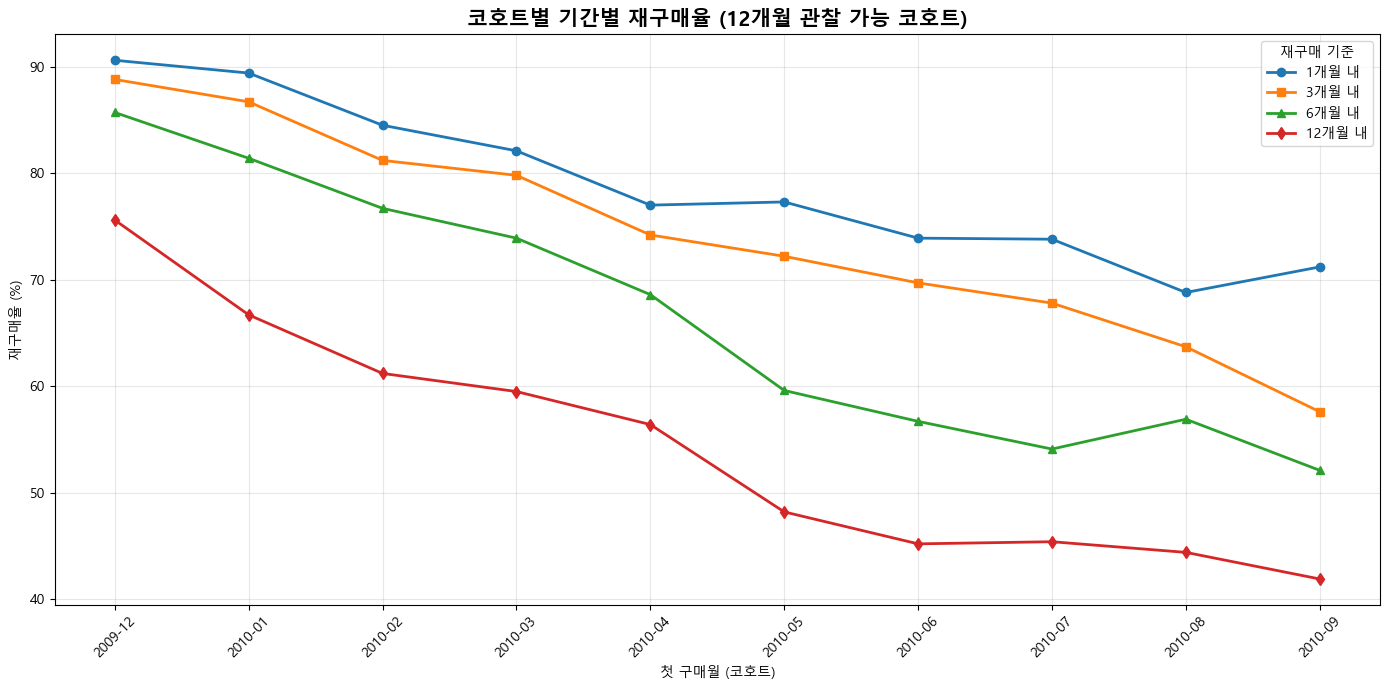


=== 인사이트 ===
12개월 재구매율 최고: 2009-12 (75.6%)
12개월 재구매율 최저: 2010-09 (41.9%)
평균 12개월 재구매율: 54.5%


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 고객별 최대 경과 개월
customer_repurchase = df.groupby('Customer ID').agg(
    CohortMonth = ('CohortMonth', 'first'),
    MaxPeriod   = ('PeriodNumber', 'max')
).reset_index()

customer_repurchase['CohortStr'] = customer_repurchase['CohortMonth'].astype(str)

# 재구매 기준별 여부
customer_repurchase['Repurchased_1M']  = (customer_repurchase['MaxPeriod'] >= 1).astype(int)
customer_repurchase['Repurchased_3M']  = (customer_repurchase['MaxPeriod'] >= 3).astype(int)
customer_repurchase['Repurchased_6M']  = (customer_repurchase['MaxPeriod'] >= 6).astype(int)
customer_repurchase['Repurchased_12M'] = (customer_repurchase['MaxPeriod'] >= 12).astype(int)

# 코호트별 재구매율
cohort_repurchase = customer_repurchase.groupby('CohortStr').agg(
    고객수      = ('Customer ID', 'count'),
    재구매_1M   = ('Repurchased_1M', lambda x: x.mean()*100),
    재구매_3M   = ('Repurchased_3M', lambda x: x.mean()*100),
    재구매_6M   = ('Repurchased_6M', lambda x: x.mean()*100),
    재구매_12M  = ('Repurchased_12M', lambda x: x.mean()*100)
).round(1)

# 2010-09까지만 필터 (12개월 관찰 가능한 코호트만)
cohort_repurchase = cohort_repurchase[cohort_repurchase.index <= '2010-09']

print("=== 코호트별 기간별 재구매율 (2009-12 ~ 2010-09) ===")
print(cohort_repurchase.to_string())

# 시각화
fig, ax = plt.subplots(figsize=(14, 7))

x = range(len(cohort_repurchase))
ax.plot(x, cohort_repurchase['재구매_1M'], marker='o', label='1개월 내', linewidth=2)
ax.plot(x, cohort_repurchase['재구매_3M'], marker='s', label='3개월 내', linewidth=2)
ax.plot(x, cohort_repurchase['재구매_6M'], marker='^', label='6개월 내', linewidth=2)
ax.plot(x, cohort_repurchase['재구매_12M'], marker='d', label='12개월 내', linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(cohort_repurchase.index, rotation=45)
ax.set_title('코호트별 기간별 재구매율 (12개월 관찰 가능 코호트)', 
             fontsize=15, fontweight='bold')
ax.set_xlabel('첫 구매월 (코호트)')
ax.set_ylabel('재구매율 (%)')
ax.legend(title='재구매 기준')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cohort_repurchase_2010_09.png', dpi=150)
plt.show()

# 인사이트
print(f"\n=== 인사이트 ===")
print(f"12개월 재구매율 최고: {cohort_repurchase['재구매_12M'].idxmax()} ({cohort_repurchase['재구매_12M'].max()}%)")
print(f"12개월 재구매율 최저: {cohort_repurchase['재구매_12M'].idxmin()} ({cohort_repurchase['재구매_12M'].min()}%)")
print(f"평균 12개월 재구매율: {cohort_repurchase['재구매_12M'].mean():.1f}%")

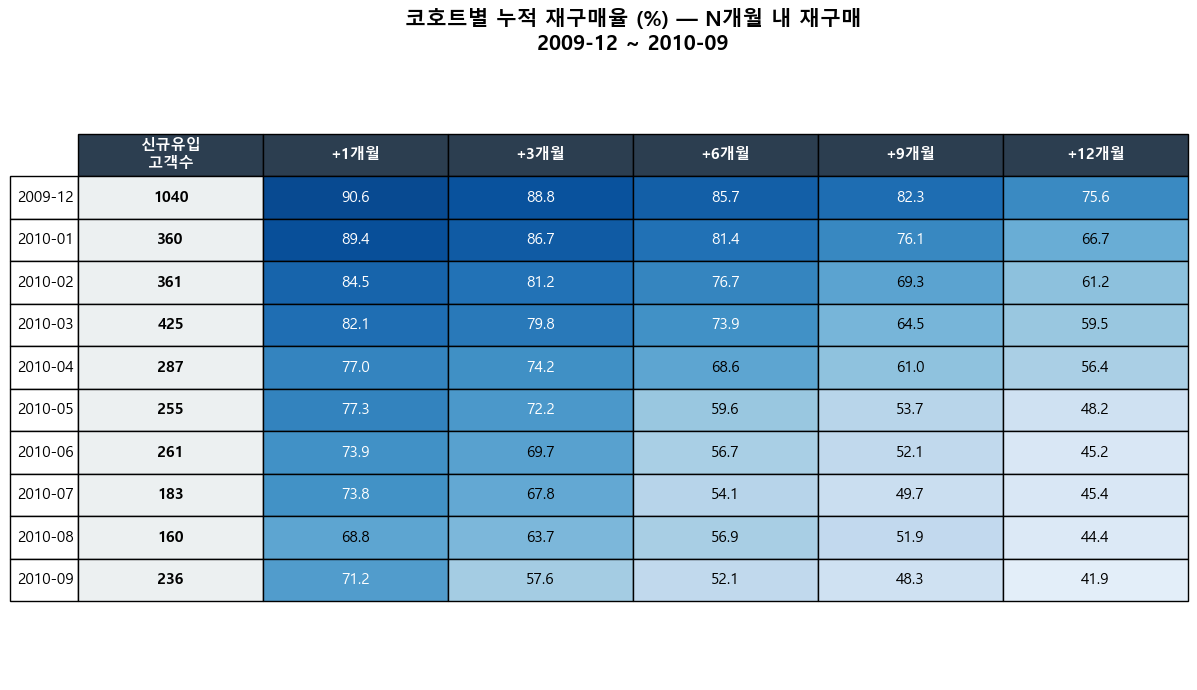

=== 누적 재구매율 표 ===
         +1개월  +3개월  +6개월  +9개월  +12개월
Cohort                                
2009-12  90.6  88.8  85.7  82.3   75.6
2010-01  89.4  86.7  81.4  76.1   66.7
2010-02  84.5  81.2  76.7  69.3   61.2
2010-03  82.1  79.8  73.9  64.5   59.5
2010-04  77.0  74.2  68.6  61.0   56.4
2010-05  77.3  72.2  59.6  53.7   48.2
2010-06  73.9  69.7  56.7  52.1   45.2
2010-07  73.8  67.8  54.1  49.7   45.4
2010-08  68.8  63.7  56.9  51.9   44.4
2010-09  71.2  57.6  52.1  48.3   41.9


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 고객별 최대 경과 개월 (이미 있으면 재사용)
customer_repurchase = df.groupby('Customer ID').agg(
    CohortMonth = ('CohortMonth', 'first'),
    MaxPeriod   = ('PeriodNumber', 'max')
).reset_index()
customer_repurchase['CohortStr'] = customer_repurchase['CohortMonth'].astype(str)

# 누적 재구매율 계산 (N개월 내 재구매)
periods = [1, 3, 6, 9, 12]
cohort_list = sorted(customer_repurchase['CohortStr'].unique())

cumulative_data = []
for cohort in cohort_list:
    cohort_customers = customer_repurchase[
        customer_repurchase['CohortStr'] == cohort
    ]
    row = {'Cohort': cohort, '신규유입': len(cohort_customers)}
    for p in periods:
        # N개월 내 재구매 = MaxPeriod >= p
        rate = (cohort_customers['MaxPeriod'] >= p).mean() * 100
        row[f'+{p}개월'] = rate
    cumulative_data.append(row)

cumulative_df = pd.DataFrame(cumulative_data).set_index('Cohort')

# 2010-09까지만 (12개월 관찰 가능)
cumulative_df = cumulative_df[cumulative_df.index <= '2010-09']

# 표 그리기
fig, ax = plt.subplots(figsize=(12, 7))
ax.axis('off')

col_labels = ['신규유입\n고객수'] + [f'+{p}개월' for p in periods]
row_labels = cumulative_df.index.tolist()

# 셀 텍스트
cell_text = []
for cohort in cumulative_df.index:
    row = [f"{int(cumulative_df.loc[cohort, '신규유입'])}"]
    for p in periods:
        val = cumulative_df.loc[cohort, f'+{p}개월']
        row.append(f'{val:.1f}')
    cell_text.append(row)

table = ax.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.1, 2.2)

# 색상: 재구매율 높을수록 진한 파랑
value_cols = [f'+{p}개월' for p in periods]
all_vals = cumulative_df[value_cols].values.flatten()
vmin, vmax = all_vals.min(), all_vals.max()

blues = plt.cm.Blues

for i, cohort in enumerate(cumulative_df.index):
    for j, p in enumerate(periods):
        val = cumulative_df.loc[cohort, f'+{p}개월']
        cell = table[i+1, j+1]
        norm = (val - vmin) / (vmax - vmin)
        color = blues(0.1 + norm * 0.8)
        cell.set_facecolor(color)
        if norm > 0.6:
            cell.set_text_props(color='white')

# 헤더
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# 신규유입 컬럼
for i in range(len(row_labels)):
    table[i+1, 0].set_facecolor('#ecf0f1')
    table[i+1, 0].set_text_props(fontweight='bold')

plt.title('코호트별 누적 재구매율 (%) — N개월 내 재구매\n2009-12 ~ 2010-09', 
          fontsize=15, fontweight='bold', pad=1)
plt.tight_layout()
plt.savefig('cohort_cumulative_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== 누적 재구매율 표 ===")
print(cumulative_df[value_cols].round(1).to_string())